Fundamentals of Dynamics and Controls Homework 4

In [ ]:
import numpy as np
import DynCon_Functions as df
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Problem 2

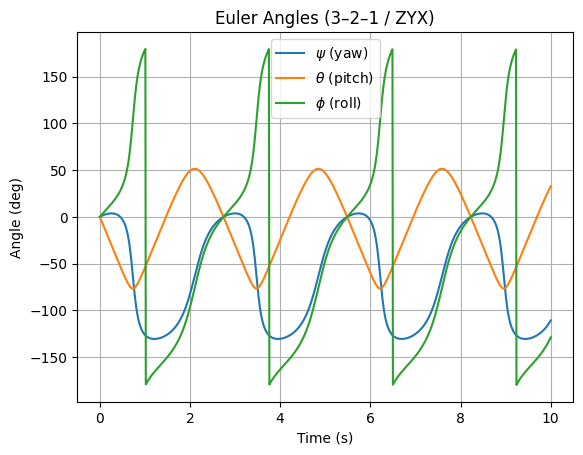

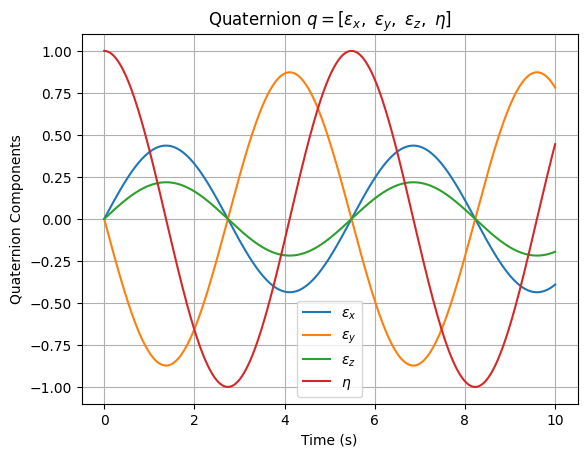

In [5]:
""" Problem 2 """

# functions
def q_dot(t, q, w):
    q = np.asarray(q, dtype=float)
    w = np.asarray(w, dtype=float)
    
    e = q[:3]
    eta = q[3]
    edot = 0.5 * (eta * w + np.cross(e, w))
    etadot = -.5 * np.dot(w, e)
    return np.hstack([edot, etadot])

def norm_quaternion(Q):
    norms = np.linalg.norm(Q, axis=1, keepdims=True)
    return Q / norms

# constants    
omega = np.array([1.0, -2.0, 0.5], dtype=float)
t0, tf = 0.0, 10.0
t_eval = np.linspace(t0, tf, 1001)
q0 = np.array([0.0, 0.0, 0.0, 1.0], dtype=float)

# analysis
sol = solve_ivp(fun=lambda t, q: q_dot(t, q, omega), t_span=(t0, tf), y0=q0, t_eval=t_eval, rtol=1e-9, atol=1e-12, method='RK45')

t = sol.t
q = sol.y.T
q = norm_quaternion(q)

angles = np.array([df.quat_to_euler321(qi) for qi in q])
phi, theta, psi = np.rad2deg(angles.T)

# plots
plt.figure()
plt.plot(t, psi, label=r"$\psi$ (yaw)")
plt.plot(t, theta, label=r"$\theta$ (pitch)")
plt.plot(t, phi, label=r"$\phi$ (roll)")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Angle (deg)")
plt.title("Euler Angles (3–2–1 / ZYX)"); plt.legend()

plt.figure()
plt.plot(t, q[:, 0], label=r"$\epsilon_x$")
plt.plot(t, q[:, 1], label=r"$\epsilon_y$")
plt.plot(t, q[:, 2], label=r"$\epsilon_z$")
plt.plot(t, q[:, 3], label=r"$\eta$")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Quaternion Components")
plt.title(r"Quaternion $q=[\epsilon_x,\ \epsilon_y,\ \epsilon_z,\ \eta]$")
plt.legend()
plt.show()